# **SUPPORT VECTOR MACHINE TUTORIAL USING PYTHON SKLEARN**

*About Dataset
It includes three iris species with 50 samples each as well as some properties of each flower. One flower species is linearly separable from the other two, but the other two are not linearly separable from each other.*

*FIle name: iris.csv*

In [158]:
import pandas as pd
from sklearn.datasets import load_iris
iris = load_iris()

In [159]:
dir(iris)

['DESCR',
 'data',
 'data_module',
 'feature_names',
 'filename',
 'frame',
 'target',
 'target_names']

In [160]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [161]:
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [162]:
df['target']= iris.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [163]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [164]:
df[df.target == 2].head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
100,6.3,3.3,6.0,2.5,2
101,5.8,2.7,5.1,1.9,2
102,7.1,3.0,5.9,2.1,2
103,6.3,2.9,5.6,1.8,2
104,6.5,3.0,5.8,2.2,2


In [165]:
df.shape

(150, 5)

In [166]:
#adding a col, named as flower_name indicates the flower which is represented to neumerical value
df['flower_name'] = df.target.apply(lambda x: iris.target_names[x])
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,flower_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [167]:
#seperating species into 3 diff dataframes
df0 = df[df.target == 0]
df1 = df[df.target == 1]
df2 = df[df.target == 1]


In [168]:
df2.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,flower_name
50,7.0,3.2,4.7,1.4,1,versicolor
51,6.4,3.2,4.5,1.5,1,versicolor
52,6.9,3.1,4.9,1.5,1,versicolor
53,5.5,2.3,4.0,1.3,1,versicolor
54,6.5,2.8,4.6,1.5,1,versicolor


In [169]:
df0.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,flower_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [170]:
df1.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,flower_name
50,7.0,3.2,4.7,1.4,1,versicolor
51,6.4,3.2,4.5,1.5,1,versicolor
52,6.9,3.1,4.9,1.5,1,versicolor
53,5.5,2.3,4.0,1.3,1,versicolor
54,6.5,2.8,4.6,1.5,1,versicolor


In [171]:
df[45:55]

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,flower_name
45,4.8,3.0,1.4,0.3,0,setosa
46,5.1,3.8,1.6,0.2,0,setosa
47,4.6,3.2,1.4,0.2,0,setosa
48,5.3,3.7,1.5,0.2,0,setosa
49,5.0,3.3,1.4,0.2,0,setosa
50,7.0,3.2,4.7,1.4,1,versicolor
51,6.4,3.2,4.5,1.5,1,versicolor
52,6.9,3.1,4.9,1.5,1,versicolor
53,5.5,2.3,4.0,1.3,1,versicolor
54,6.5,2.8,4.6,1.5,1,versicolor


In [172]:
#libraries for viswalization
from matplotlib import pyplot as plt
%matplotlib inline

**Sepal length VS Sepal width (Setosa vs Versicolor):**

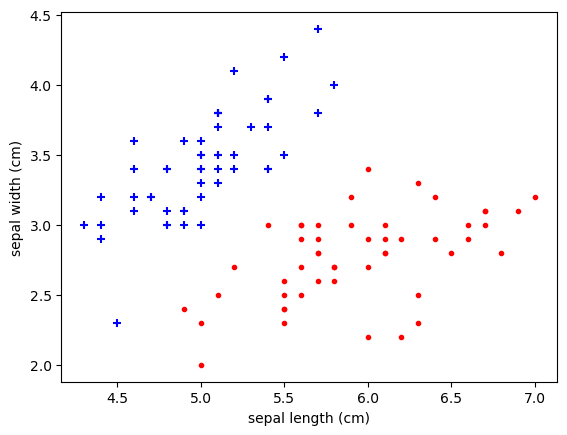

In [173]:
#use only first two features because its a 2D plot
plt.scatter(df0['sepal length (cm)'],df0['sepal width (cm)'], color ='blue', marker ='+')#specify x and y
plt.scatter(df1['sepal length (cm)'],df1['sepal width (cm)'], color ='red', marker ='.')
plt.xlabel('sepal length (cm)')
plt.ylabel('sepal width (cm)')
plt.show()

**Petal length vs Petal width (Setosa vs versicolor)**

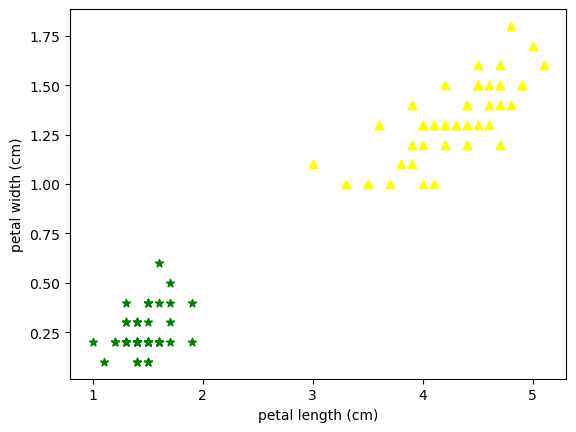

In [174]:
#Using other two features 
plt.scatter(df0['petal length (cm)'],df0['petal width (cm)'], color ='green', marker ='*')#specify x and y
plt.scatter(df1['petal length (cm)'],df1['petal width (cm)'], color ='yellow', marker ='^')
plt.xlabel('petal length (cm)')
plt.ylabel('petal width (cm)')
plt.show()

### **Train Using SVM**

In [175]:
from sklearn.model_selection import train_test_split

In [176]:
x = df.drop(['target', 'flower_name'], axis = 'columns')
y =df.target

In [177]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

In [178]:
len(x_train)

120

In [179]:
len(x_test)

30

In [180]:
from sklearn.svm import SVC
model = SVC()

In [181]:
model.fit(x_train, y_train)

SVC()

In [182]:
model.get_params()

{'C': 1.0,
 'break_ties': False,
 'cache_size': 200,
 'class_weight': None,
 'coef0': 0.0,
 'decision_function_shape': 'ovr',
 'degree': 3,
 'gamma': 'scale',
 'kernel': 'rbf',
 'max_iter': -1,
 'probability': False,
 'random_state': None,
 'shrinking': True,
 'tol': 0.001,
 'verbose': False}

In [183]:
model.score(x_test, y_test)  #increasing regularization actually decreases the score (i put [C=10])

0.9666666666666667

In [184]:
model.predict([[4.8, 3.0, 1.5, 0.3]])

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


array([0])

### **Tune Parameters**

**1) Regularization(C)**

In [185]:
#Small C → wider margin, more regularization → model may misclassify some points.
#Large C → narrower margin, less regularization → model tries to classify training data more exactly.
#Large C → narrower margin, less regularization → model tries to classify training data more exactly.


model_C = SVC(C=1)
model_C.fit(x_train, y_train)
model_C.score(x_test, y_test)

#controls the tradeoff between:
#low bias (fitting training data well), and
#low variance (keeping the margin wider, tolerating misclassifications).

0.9666666666666667

In [186]:
model_C = SVC(C=2)
model_C.fit(x_train, y_train)
model_C.score(x_test, y_test)

0.9333333333333333

**2) Gamma**

In [187]:
model_g = SVC(gamma = 10)
model_g.fit(x_train, y_train)
model_g.score(x_test, y_test)

0.9

**3) Kernel**

In [188]:
model_linear_kernel = SVC(kernel = 'linear')
model_linear_kernel.fit(x_train, y_train)

SVC(kernel='linear')

In [189]:
model_linear_kernel.score(x_test, y_test)

0.9333333333333333